In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('/content/HR Employee Attrition Analysis.xltx')

3. Data Understanding

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# ukuran data
df.shape

(1470, 35)

In [5]:
#Kolom nama
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [6]:
#informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
#deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
#statistik kolom kategorikal
df.describe(include='object').T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


4. Missing Values

In [9]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#Cek unik value
for col in df.select_dtypes(include='object').columns:
    print(f'\n{col}')
    print(df[col].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


In [12]:
#cek kolom konstan
constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

constant_cols

['EmployeeCount', 'Over18', 'StandardHours']

kolom tersebut tidak memberikan variasi informasi untuk analisis.

In [13]:
df = df.drop(columns=constant_cols)

In [14]:
# cek outlier
df[['Age',
    'MonthlyIncome',
    'TotalWorkingYears',
    'YearsAtCompany']].describe()

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,11.279592,7.008163
std,9.135373,4707.956783,7.780782,6.126525
min,18.000000,1009.000000,0.000000,0.000000
25%,30.000000,2911.000000,6.000000,3.000000
50%,36.000000,4919.000000,10.000000,5.000000
75%,43.000000,8379.000000,15.000000,9.000000
max,60.000000,19999.000000,40.000000,40.000000


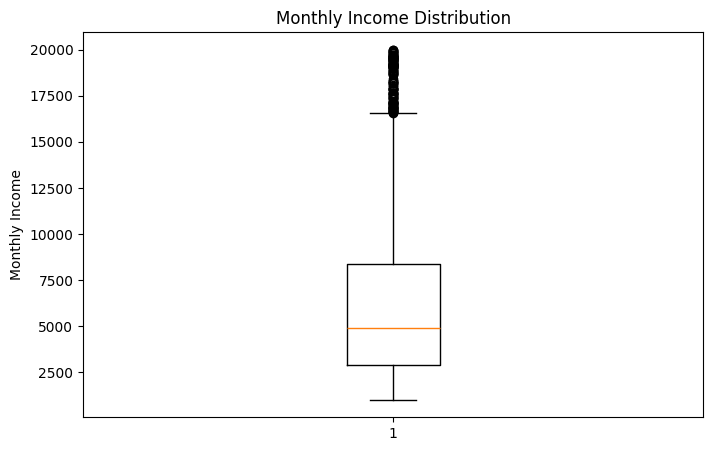

In [15]:
# Boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(df['MonthlyIncome'])
plt.title('Monthly Income Distribution')
plt.ylabel('Monthly Income')
plt.show()

In [16]:
# Calculate IQR
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 2911.0
Q3: 8379.0
IQR: 5468.0
Lower Bound: -5291.0
Upper Bound: 16581.0


In [17]:
income_outliers = df[
    (df['MonthlyIncome'] < lower_bound) |
    (df['MonthlyIncome'] > upper_bound)
]

print("Total Outliers:", len(income_outliers))

Total Outliers: 114


In [18]:
income_outliers[
    ['MonthlyIncome', 'JobRole', 'JobLevel', 'YearsAtCompany', 'TotalWorkingYears']
].sort_values('MonthlyIncome', ascending=False).head(20)

,MonthlyIncome,JobRole,JobLevel,YearsAtCompany,TotalWorkingYears
190,19999,Manager,5,33,34
746,19973,Research Director,5,21,21
851,19943,Manager,5,5,28
165,19926,Manager,5,5,21
568,19859,Manager,5,5,24
918,19847,Manager,5,29,31
749,19845,Manager,5,32,33
1242,19833,Manager,5,21,21
898,19740,Research Director,5,8,25
956,19717,Manager,5,7,36


Outliers were identified in Monthly Income using the IQR method. However, these values were retained because they represent plausible salary differences across job roles and seniority levels rather than data errors.

Feature Engineering

In [19]:
# Attrition FLag
df['AttritionFlag'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [20]:
# AGe Grup
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        '<25',
        '25-34',
        '35-44',
        '45-54',
        '55+'
    ],
    right=False
)

In [21]:
# income grup
df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=[
        'Low',
        'Lower-Middle',
        'Upper-Middle',
        'High'
    ]
)

In [22]:
# Tanure grup
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 20, float('inf')],
    labels=[
        '0-2 Years',
        '3-5 Years',
        '6-10 Years',
        '11-20 Years',
        '20+ Years'
    ]
)

Cek Hasil Cleaning barusan

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   object  
 2   BusinessTravel            1470 non-null   object  
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   object  
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   object  
 8   EmployeeNumber            1470 non-null   int64   
 9   EnvironmentSatisfaction   1470 non-null   int64   
 10  Gender                    1470 non-null   object  
 11  HourlyRate                1470 non-null   int64   
 12  JobInvolvement            1470 non-null   int64   
 13  JobLevel                  1470 non-null   int64 

In [24]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag,AgeGroup,IncomeGroup,TenureGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,1,6,4,0,5,1,35-44,Upper-Middle,6-10 Years
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,3,10,7,1,7,0,45-54,Upper-Middle,6-10 Years
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,3,0,0,0,0,1,35-44,Low,0-2 Years
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,8,7,3,0,0,25-34,Low,6-10 Years
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,3,2,2,2,2,0,25-34,Lower-Middle,0-2 Years


In [25]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeNumber,0
EnvironmentSatisfaction,0


In [26]:
df.shape

(1470, 36)

EDA

In [27]:
#OVERALL Attrition
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [28]:
# Attrition by Departemen
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [29]:
# Attretion by Job Role
job_attrition = (
    df.groupby('JobRole')['AttritionFlag']
    .agg(['count', 'sum', 'mean'])
)

job_attrition['mean'] = job_attrition['mean'] * 100

job_attrition.sort_values(
    'mean',
    ascending=False
)

,count,sum,mean
JobRole,,,
Sales Representative,83,33,39.759036
Laboratory Technician,259,62,23.938224
Human Resources,52,12,23.076923
Sales Executive,326,57,17.484663
Research Scientist,292,47,16.095890
Manufacturing Director,145,10,6.896552
Healthcare Representative,131,9,6.870229
Manager,102,5,4.901961
Research Director,80,2,2.500000


In [30]:
# Attrition by overtime
overtime_attrition = (
    df.groupby('OverTime')['AttritionFlag']
    .mean() * 100
)

overtime_attrition

,AttritionFlag
OverTime,
No,10.436433
Yes,30.528846


In [31]:
# Attrition by age
age_attrition = (
    df.groupby(
        'AgeGroup',
        observed=False
    )['AttritionFlag']
    .mean() * 100
)

age_attrition

,AttritionFlag
AgeGroup,
<25,39.175258
25-34,20.216606
35-44,10.099010
45-54,10.204082
55+,15.942029


In [32]:
# Attretion by Income Group
income_attrition = (
    df.groupby(
        'IncomeGroup',
        observed=False
    )['AttritionFlag']
    .mean() * 100
)

income_attrition

,AttritionFlag
IncomeGroup,
Low,29.268293
Lower-Middle,14.207650
Upper-Middle,10.626703
High,10.326087


In [33]:
# Attrition by Tenure
tenure_attrition = (
    df.groupby(
        'TenureGroup',
        observed=False
    )['AttritionFlag']
    .mean() * 100
)

tenure_attrition

,AttritionFlag
TenureGroup,
0-2 Years,29.824561
3-5 Years,13.824885
6-10 Years,12.276786
11-20 Years,6.666667
20+ Years,12.121212


In [34]:
# job satification
satisfaction_attrition = (
    df.groupby('JobSatisfaction')['AttritionFlag']
    .mean() * 100
)

satisfaction_attrition

,AttritionFlag
JobSatisfaction,
1,22.837370
2,16.428571
3,16.515837
4,11.328976


In [35]:
# work life balance
wlb_attrition = (
    df.groupby('WorkLifeBalance')['AttritionFlag']
    .mean() * 100
)

wlb_attrition

,AttritionFlag
WorkLifeBalance,
1,31.250000
2,16.860465
3,14.221725
4,17.647059


In [36]:
# business travel
travel_attrition = (
    df.groupby('BusinessTravel')['AttritionFlag']
    .mean() * 100
)

travel_attrition

,AttritionFlag
BusinessTravel,
Non-Travel,8.000000
Travel_Frequently,24.909747
Travel_Rarely,14.956855


In [37]:
# Select numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation
correlation_matrix = numeric_df.corr()

correlation_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
Age,1.000000,0.010661,-0.001686,0.208034,-0.010145,0.010146,0.024287,0.029820,0.509604,-0.004892,...,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,-0.159205
DailyRate,0.010661,1.000000,-0.004985,-0.016806,-0.050990,0.018355,0.023381,0.046135,0.002966,0.030571,...,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,-0.056652
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,0.032916,-0.016075,0.031131,0.008783,0.005303,-0.003669,...,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.077924
Education,0.208034,-0.016806,0.021042,1.000000,0.042070,-0.027128,0.016775,0.042438,0.101589,-0.011296,...,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,-0.031373
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,1.000000,0.017621,0.035179,-0.006888,-0.018519,-0.046247,...,-0.069861,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197,-0.010577
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,0.017621,1.000000,-0.049857,-0.008278,0.001212,-0.006784,...,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999,-0.103369
HourlyRate,0.024287,0.023381,0.031131,0.016775,0.035179,-0.049857,1.000000,0.042861,-0.027853,-0.071335,...,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123,-0.006846
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.006888,-0.008278,0.042861,1.000000,-0.012630,-0.021476,...,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976,-0.130016
JobLevel,0.509604,0.002966,0.005303,0.101589,-0.018519,0.001212,-0.027853,-0.012630,1.000000,-0.001944,...,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281,-0.169105
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.046247,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,...,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656,-0.103481


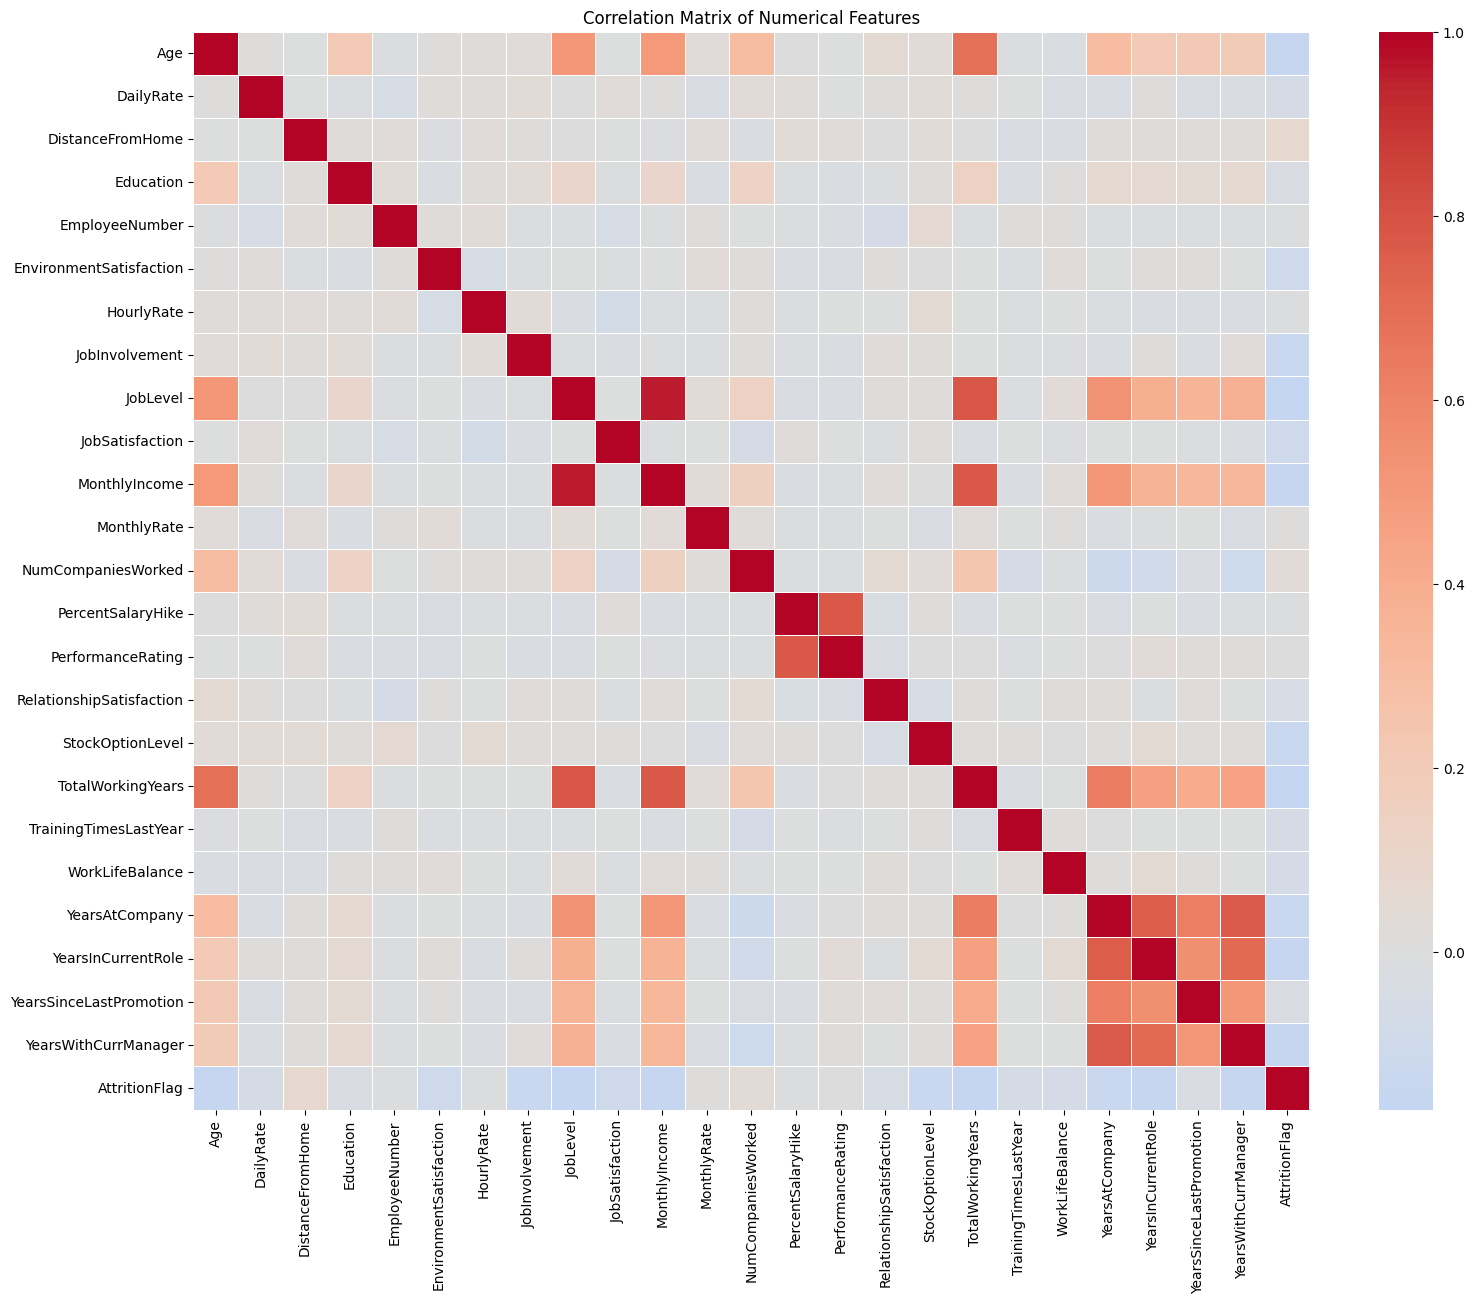

In [38]:
import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [39]:
# Export clean dataset
df.to_excel(
    'HR_Employee_Attrition_Clean.xlsx',
    index=False
)

In [40]:
from google.colab import files
files.download('HR_Employee_Attrition_Clean.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

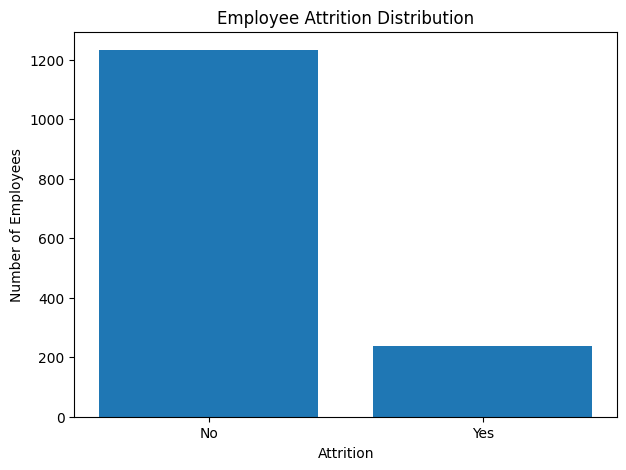

In [41]:
#Attrition Distribution

plt.figure(figsize=(7, 5))

attrition_counts = df['Attrition'].value_counts()

plt.bar(
    attrition_counts.index,
    attrition_counts.values
)

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

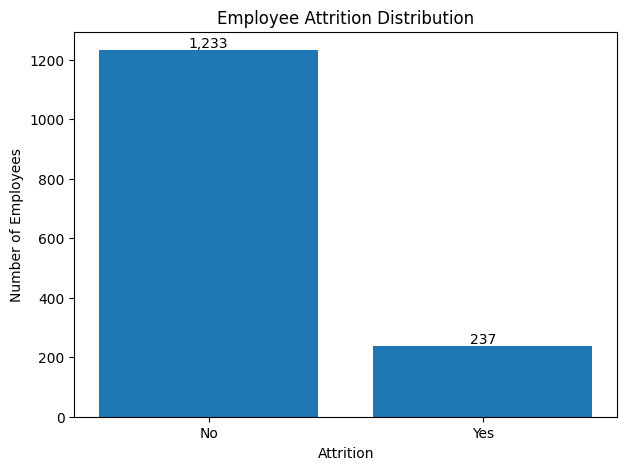

In [42]:
#Attrition Rate by Departement

plt.figure(figsize=(7, 5))

attrition_counts = df['Attrition'].value_counts()

bars = plt.bar(
    attrition_counts.index,
    attrition_counts.values
)

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom'
    )

plt.show()

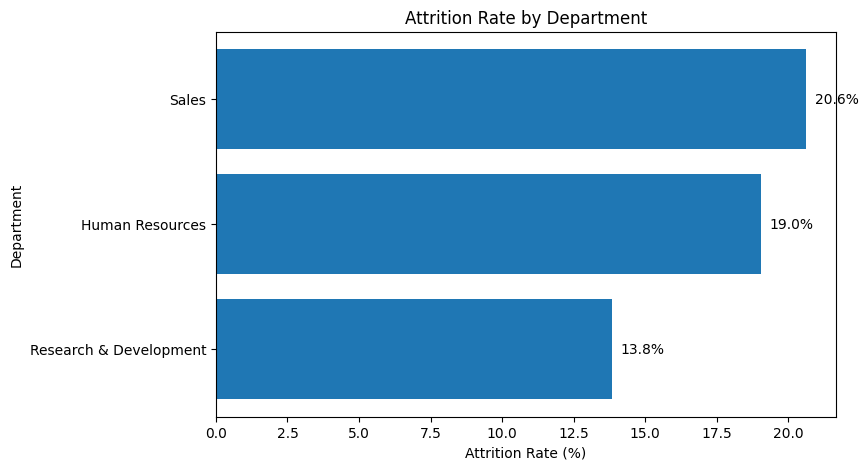

In [44]:
plt.figure(figsize=(8, 5))

bars = plt.barh(
    department_attrition.index,
    department_attrition.values
)

plt.title('Attrition Rate by Department')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Department')

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}%',
        va='center'
    )

plt.show()

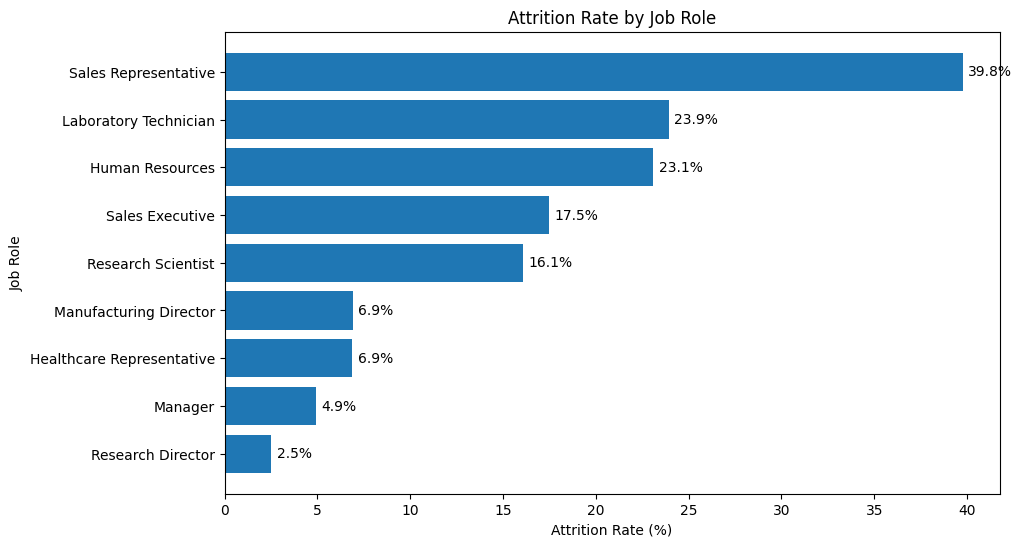

In [46]:
#Attrition Rate by Job Role

plt.figure(figsize=(10, 6))

bars = plt.barh(
    jobrole_attrition.index,
    jobrole_attrition.values
)

plt.title('Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}%',
        va='center'
    )

plt.show()

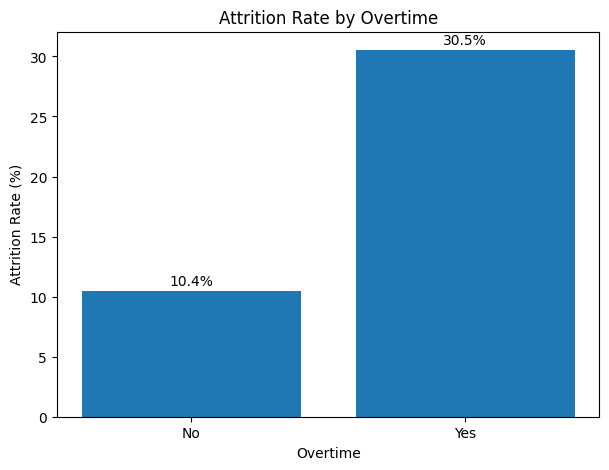

In [47]:
#Attrition Rate by Overtime

plt.figure(figsize=(7, 5))

bars = plt.bar(
    overtime_attrition.index,
    overtime_attrition.values
)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.show()

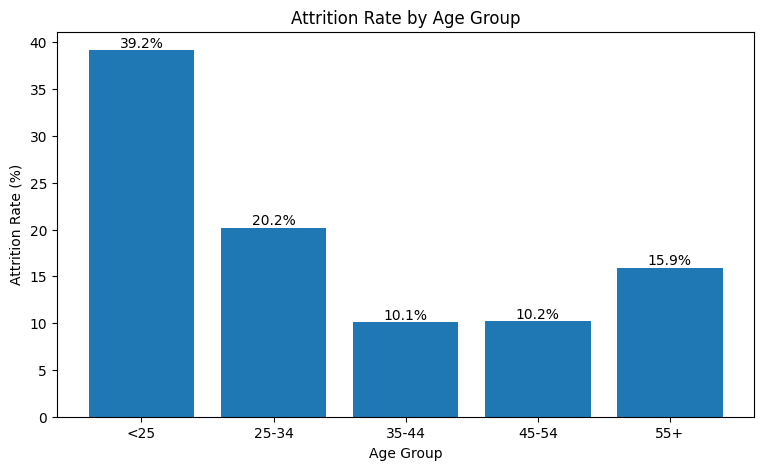

In [48]:
#Attrition Rate by Age Group

plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_attrition.index.astype(str),
    age_attrition.values
)

plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.show()

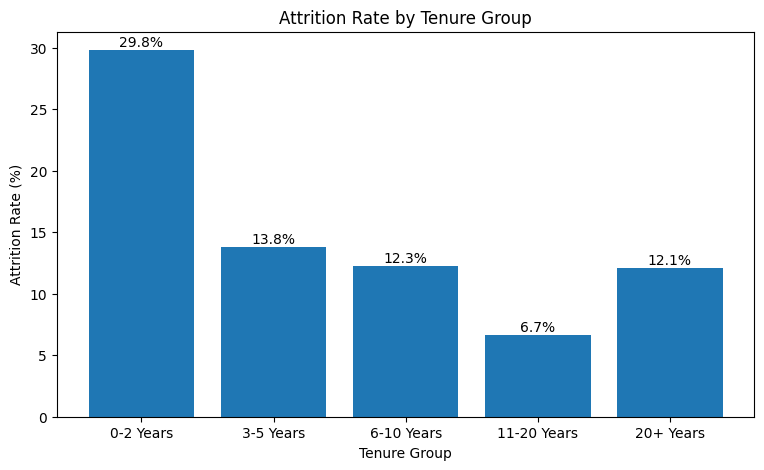

In [49]:
# Attrition Rate by Tenure

plt.figure(figsize=(9, 5))

bars = plt.bar(
    tenure_attrition.index.astype(str),
    tenure_attrition.values
)

plt.title('Attrition Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Attrition Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.show()

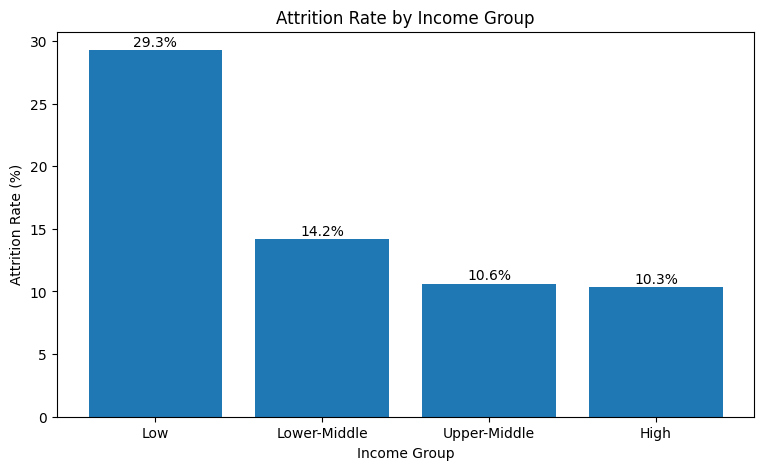

In [51]:
#Attrition Rate by Income Group

plt.figure(figsize=(9, 5))

bars = plt.bar(
    income_attrition.index.astype(str),
    income_attrition.values
)

plt.title('Attrition Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Attrition Rate (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center'
    )

plt.show()